In [1]:
# Imports and Configuration
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import json
import warnings
warnings.filterwarnings('ignore')

# Configuration
SEED = 42
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_DIMS = [512, 256, 128]
DROPOUT_RATE = 0.3
NUM_LABELS = 3
LABEL_COLS = ['Sweet', 'Bitter', 'Umami']

np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 1. Data Loading

In [2]:
# Load data
mol2vec_df = pd.read_csv('Embeddings/chemtastes_mol2vec.csv')
chemberta_df = pd.read_csv('Embeddings/chemtastes_chemberta.csv')

mol2vec_cols = [col for col in mol2vec_df.columns if col.startswith('mol2vec_')]
chemberta_cols = [col for col in chemberta_df.columns if col.startswith('chemberta_')]

mol2vec_features = mol2vec_df[mol2vec_cols].values
chemberta_features = chemberta_df[chemberta_cols].values
y = mol2vec_df[LABEL_COLS].values

print(f"Mol2Vec: {mol2vec_features.shape}, ChemBERTa: {chemberta_features.shape}, Labels: {y.shape}")

Mol2Vec: (3849, 300), ChemBERTa: (3849, 768), Labels: (3849, 3)


In [3]:
# Combine embeddings
X = np.concatenate([mol2vec_features, chemberta_features], axis=1)
print(f"Combined features: {X.shape}")

Combined features: (3849, 1068)


In [4]:
# Train/Val/Test Split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y[:, 1])
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp[:, 1])

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 2694, Val: 577, Test: 578


In [5]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Features standardized")

Features standardized


## 2. Class Weights

In [6]:
# Compute class weights for handling imbalanced classes
def compute_class_weights(y_train, label_cols, method='sqrt_inv'):
    """Compute class weights using inverse frequency with sqrt smoothing."""
    weights = []
    for i, label in enumerate(label_cols):
        pos = y_train[:, i].sum()
        neg = len(y_train) - pos
        ratio = neg / pos if pos > 0 else 1.0
        weights.append(np.sqrt(ratio) if method == 'sqrt_inv' else ratio)
    return torch.tensor(weights, dtype=torch.float32)

pos_weights = compute_class_weights(y_train, LABEL_COLS).to(device)
print(f"Class weights: {dict(zip(LABEL_COLS, pos_weights.cpu().numpy().round(2)))}")

Class weights: {'Sweet': np.float32(1.33), 'Bitter': np.float32(1.09), 'Umami': np.float32(3.52)}


## 3. Dataset & DataLoader

In [7]:
# Dataset and DataLoader
class MolecularTasteDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MolecularTasteDataset(X_train_scaled, y_train)
val_dataset = MolecularTasteDataset(X_val_scaled, y_val)
test_dataset = MolecularTasteDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"DataLoaders created (batch_size={BATCH_SIZE})")

DataLoaders created (batch_size=32)



## 4. Model Architecture

In [8]:
# Multi-Label Taste Classifier
class MultiLabelTasteClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 128], num_labels=3, dropout_rate=0.3):
        super().__init__()
        
        # Shared layers
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
        self.shared = nn.Sequential(*layers)
        
        # Output heads (one per label)
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden_dims[-1], 32), nn.ReLU(), nn.Dropout(dropout_rate/2), nn.Linear(32, 1))
            for _ in range(num_labels)
        ])
    
    def forward(self, x):
        shared_out = self.shared(x)
        return torch.cat([head(shared_out) for head in self.heads], dim=1)

INPUT_DIM = X_train_scaled.shape[1]
model = MultiLabelTasteClassifier(INPUT_DIM, HIDDEN_DIMS, NUM_LABELS, DROPOUT_RATE).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 725,827


## 5. Loss & Optimizer

In [9]:
# Focal Loss for handling class imbalance
class FocalLossWithLogits(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight
        self.reduction = reduction
    
    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none'
        )
        pt = torch.exp(-bce)
        focal_loss = ((1 - pt) ** self.gamma) * bce
        return focal_loss.sum() if self.reduction == 'sum' else focal_loss.mean()

criterion = FocalLossWithLogits(gamma=2.0, pos_weight=pos_weights, reduction='sum')
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
print("Optimizer: AdamW, Loss: FocalLoss")

Optimizer: AdamW, Loss: FocalLoss


## 6. Evaluation Metrics

In [10]:
# Evaluation metrics
def compute_metrics(y_true, y_proba, y_pred, label_names):
    """Compute evaluation metrics for multi-label classification."""
    metrics = {}
    aurocs, f1s = [], []
    
    for i, label in enumerate(label_names):
        if len(np.unique(y_true[:, i])) > 1:
            metrics[f'{label}_AUROC'] = roc_auc_score(y_true[:, i], y_proba[:, i])
            aurocs.append(metrics[f'{label}_AUROC'])
        else:
            metrics[f'{label}_AUROC'] = 0.5
        metrics[f'{label}_F1'] = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
        f1s.append(metrics[f'{label}_F1'])
    
    metrics['macro_AUROC'] = np.mean(aurocs) if aurocs else 0.5
    metrics['macro_F1'] = np.mean(f1s)
    metrics['exact_match_accuracy'] = accuracy_score(y_true, y_pred)
    return metrics

def evaluate_model(model, dataloader, criterion, device, label_names):
    """Evaluate model on a dataset."""
    model.eval()
    all_labels, all_proba, all_preds = [], [], []
    total_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            total_loss += criterion(logits, y_batch).item()
            proba = torch.sigmoid(logits)
            all_labels.append(y_batch.cpu().numpy())
            all_proba.append(proba.cpu().numpy())
            all_preds.append((proba >= 0.5).float().cpu().numpy())
    
    y_true, y_proba, y_pred = np.vstack(all_labels), np.vstack(all_proba), np.vstack(all_preds)
    metrics = compute_metrics(y_true, y_proba, y_pred, label_names)
    metrics['loss'] = total_loss / len(dataloader.dataset)
    return metrics, y_true, y_proba, y_pred

print("Evaluation functions defined")

Evaluation functions defined


## 7. Training

In [11]:
# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                device, label_names, num_epochs=100, patience=15, verbose=True):
    """Train model with early stopping."""
    history = {'train_loss': [], 'val_loss': [], 'val_macro_AUROC': [], 'val_macro_F1': []}
    for label in label_names:
        history[f'val_{label}_AUROC'] = []
        history[f'val_{label}_F1'] = []
    
    best_auroc, best_state, no_improve = 0.0, None, 0
    
    for epoch in range(num_epochs):
        # Train
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        # Evaluate
        train_metrics, _, _, _ = evaluate_model(model, train_loader, criterion, device, label_names)
        val_metrics, _, _, _ = evaluate_model(model, val_loader, criterion, device, label_names)
        scheduler.step(val_metrics['loss'])
        
        # Record history
        history['train_loss'].append(train_metrics['loss'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_macro_AUROC'].append(val_metrics['macro_AUROC'])
        history['val_macro_F1'].append(val_metrics['macro_F1'])
        for label in label_names:
            history[f'val_{label}_AUROC'].append(val_metrics[f'{label}_AUROC'])
            history[f'val_{label}_F1'].append(val_metrics[f'{label}_F1'])
        
        # Early stopping
        if val_metrics['macro_AUROC'] > best_auroc:
            best_auroc = val_metrics['macro_AUROC']
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
            marker = ' *'
        else:
            no_improve += 1
            marker = ''
        
        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(f"Epoch {epoch+1:3d} | Loss: {train_metrics['loss']:.4f}/{val_metrics['loss']:.4f} | "
                  f"AUROC: {val_metrics['macro_AUROC']:.4f} | F1: {val_metrics['macro_F1']:.4f}{marker}")
        
        if no_improve >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break
    
    if best_state:
        model.load_state_dict(best_state)
    return history, best_auroc

print("Training function defined")

Training function defined


In [12]:
# Plot training history
def plot_training_history(history, label_names):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    
    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'], label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].set_title('Loss')
    
    axes[1].plot(epochs, history['val_macro_AUROC']); axes[1].set_ylim([0.5, 1])
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUROC'); axes[1].set_title('Macro AUROC')
    
    for label in label_names:
        axes[2].plot(epochs, history[f'val_{label}_AUROC'], label=label)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUROC'); axes[2].legend(); axes[2].set_title('Per-Label AUROC')
    
    plt.tight_layout()
    plt.show()

print("Plotting function defined")

Plotting function defined


## 8. Train Model

Training model...
Epoch   1 | Loss: 0.3739/0.3819 | AUROC: 0.8915 | F1: 0.7128 *
Epoch   1 | Loss: 0.3739/0.3819 | AUROC: 0.8915 | F1: 0.7128 *
Epoch  10 | Loss: 0.2175/0.4104 | AUROC: 0.9182 | F1: 0.7462
Epoch  10 | Loss: 0.2175/0.4104 | AUROC: 0.9182 | F1: 0.7462
Epoch  20 | Loss: 0.1204/0.4659 | AUROC: 0.9253 | F1: 0.7684
Epoch  20 | Loss: 0.1204/0.4659 | AUROC: 0.9253 | F1: 0.7684
Epoch  30 | Loss: 0.0810/0.5895 | AUROC: 0.9297 | F1: 0.7772
Epoch  30 | Loss: 0.0810/0.5895 | AUROC: 0.9297 | F1: 0.7772
Early stopping at epoch 37

Best validation AUROC: 0.9327
Early stopping at epoch 37

Best validation AUROC: 0.9327


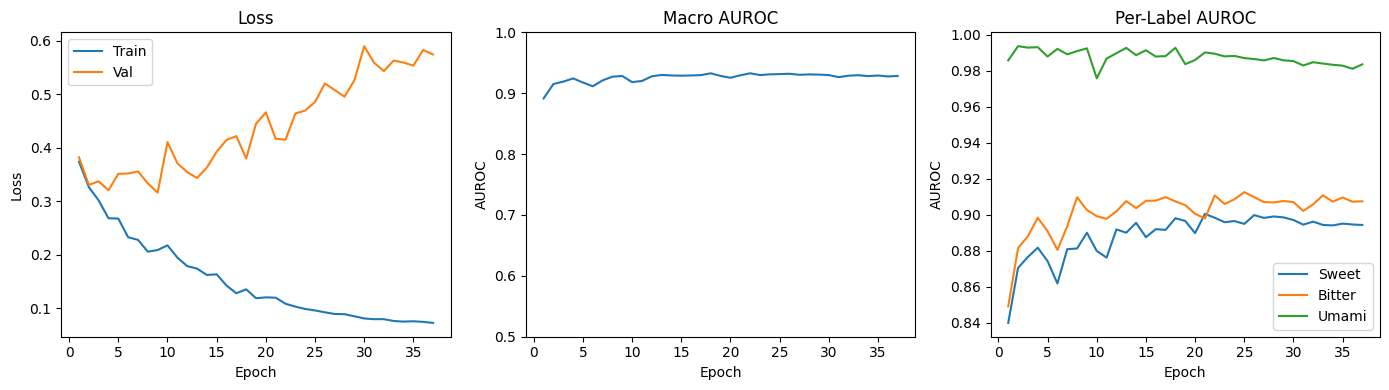

In [13]:
# Train model
print("Training model...")
history, best_auroc = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                                   device, LABEL_COLS, num_epochs=100, patience=15)
print(f"\nBest validation AUROC: {best_auroc:.4f}")
plot_training_history(history, LABEL_COLS)

## 9. Test Evaluation

In [14]:
# Test set evaluation
test_metrics, y_true_test, y_proba_test, y_pred_test = evaluate_model(model, test_loader, criterion, device, LABEL_COLS)

print(f"Test Results:")
print(f"  Macro AUROC: {test_metrics['macro_AUROC']:.4f}")
print(f"  Macro F1: {test_metrics['macro_F1']:.4f}")
print(f"  Exact Match: {test_metrics['exact_match_accuracy']:.4f}")
for label in LABEL_COLS:
    print(f"  {label}: AUROC={test_metrics[f'{label}_AUROC']:.4f}, F1={test_metrics[f'{label}_F1']:.4f}")

Test Results:
  Macro AUROC: 0.9289
  Macro F1: 0.7782
  Exact Match: 0.6834
  Sweet: AUROC=0.9037, F1=0.7467
  Bitter: AUROC=0.9133, F1=0.8040
  Umami: AUROC=0.9697, F1=0.7840


In [15]:
# Label distribution
for i, label in enumerate(LABEL_COLS):
    pos = y_test[:, i].sum()
    print(f"{label}: {int(pos)} positive ({pos/len(y_test)*100:.1f}%)")

Sweet: 200 positive (34.6%)
Bitter: 264 positive (45.7%)
Umami: 55 positive (9.5%)


## 10. Confusion Matrices

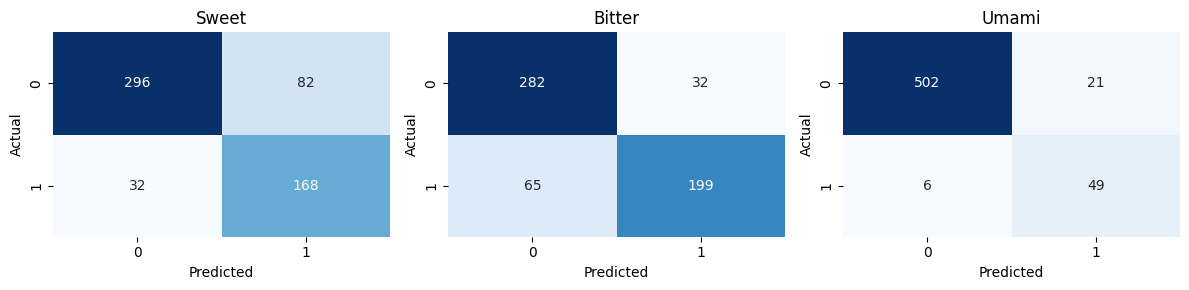

In [16]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, label in enumerate(LABEL_COLS):
    cm = confusion_matrix(y_true_test[:, i], y_pred_test[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(label); axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 11. ROC Curves

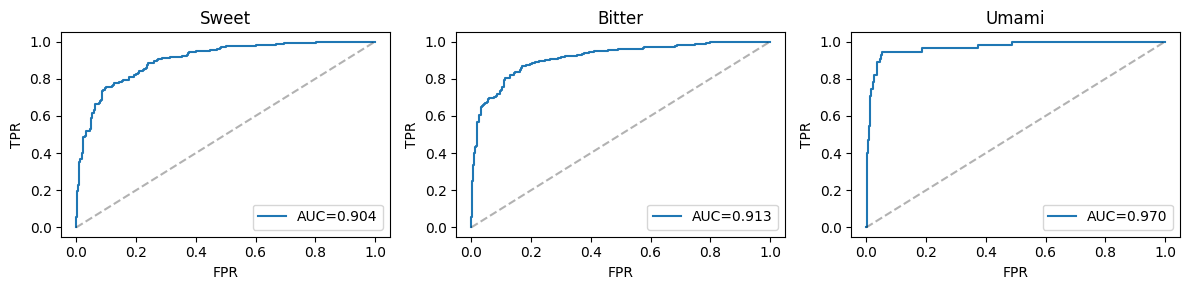

In [17]:
# ROC curves
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, label in enumerate(LABEL_COLS):
    fpr, tpr, _ = roc_curve(y_true_test[:, i], y_proba_test[:, i])
    auc = test_metrics[f'{label}_AUROC']
    axes[i].plot(fpr, tpr, label=f'AUC={auc:.3f}')
    axes[i].plot([0,1], [0,1], 'k--', alpha=0.3)
    axes[i].set_title(label); axes[i].set_xlabel('FPR'); axes[i].set_ylabel('TPR'); axes[i].legend()
plt.tight_layout()
plt.show()

## 12. Save Model

In [18]:
# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'config': {'input_dim': INPUT_DIM, 'hidden_dims': HIDDEN_DIMS, 'num_labels': NUM_LABELS, 'dropout_rate': DROPOUT_RATE}
}, 'taste_classifier_model.pth')

with open('taste_mapping.json', 'w') as f:
    json.dump({'labels': LABEL_COLS}, f)
print("Model saved")

Model saved


## 12. Save Model

In [19]:
# Inference function
def predict_taste(mol2vec_feat, chemberta_feat, model, scaler, device, threshold=0.5):
    """Predict taste from molecular embeddings."""
    X = np.concatenate([mol2vec_feat.reshape(1, -1), chemberta_feat.reshape(1, -1)], axis=1)
    X_scaled = scaler.transform(X)
    
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_scaled, dtype=torch.float32).to(device))
        proba = torch.sigmoid(logits).cpu().numpy()[0]
    
    return {label: {'probability': float(proba[i]), 'predicted': bool(proba[i] >= threshold)} 
            for i, label in enumerate(LABEL_COLS)}

# Test inference
sample_result = predict_taste(mol2vec_features[0], chemberta_features[0], model, scaler, device)
print("Sample prediction:", sample_result)

Sample prediction: {'Sweet': {'probability': 0.0030510618817061186, 'predicted': False}, 'Bitter': {'probability': 0.9847368597984314, 'predicted': True}, 'Umami': {'probability': 0.00023292345576919615, 'predicted': False}}


## 13. Inference

In [20]:
# Model summary
print(f"Model Summary:")
print(f"  Input: {INPUT_DIM}d (Mol2Vec 300d + ChemBERTa 768d)")
print(f"  Hidden: {HIDDEN_DIMS}")
print(f"  Output: {NUM_LABELS} labels ({', '.join(LABEL_COLS)})")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model Summary:
  Input: 1068d (Mol2Vec 300d + ChemBERTa 768d)
  Hidden: [512, 256, 128]
  Output: 3 labels (Sweet, Bitter, Umami)
  Parameters: 725,827


## 14. PCA Comparison

=== PCA vs Non-PCA Comparison ===

PCA: 1068 → 196 dimensions (95.0% variance)

Training Non-PCA model...
PCA: 1068 → 196 dimensions (95.0% variance)

Training Non-PCA model...
  Best AUROC: 0.9319
Training PCA model...
  Best AUROC: 0.9319
Training PCA model...
  Best AUROC: 0.9249

Metric                  Non-PCA        PCA       Diff
--------------------------------------------------
macro_AUROC              0.9288     0.9291    +0.0003
macro_F1                 0.7994     0.7706    -0.0288
exact_match_accuracy     0.7007     0.6696    -0.0311
  Best AUROC: 0.9249

Metric                  Non-PCA        PCA       Diff
--------------------------------------------------
macro_AUROC              0.9288     0.9291    +0.0003
macro_F1                 0.7994     0.7706    -0.0288
exact_match_accuracy     0.7007     0.6696    -0.0311


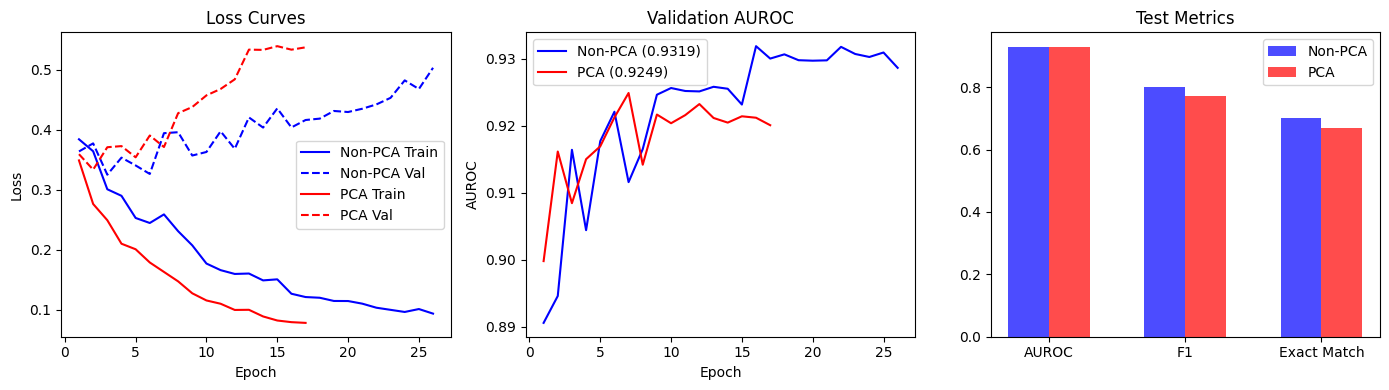


Conclusion: PCA maintains comparable performance


In [21]:
# PCA Comparison Study
from sklearn.decomposition import PCA

print("=== PCA vs Non-PCA Comparison ===\n")

# Apply PCA
VARIANCE_THRESHOLD = 0.95
pca = PCA(n_components=VARIANCE_THRESHOLD, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)
n_components = X_train_pca.shape[1]

print(f"PCA: {X_train_scaled.shape[1]} → {n_components} dimensions ({pca.explained_variance_ratio_.sum()*100:.1f}% variance)")

# Create datasets
train_nopca = MolecularTasteDataset(X_train_scaled, y_train)
val_nopca = MolecularTasteDataset(X_val_scaled, y_val)
test_nopca = MolecularTasteDataset(X_test_scaled, y_test)
train_pca_ds = MolecularTasteDataset(X_train_pca, y_train)
val_pca_ds = MolecularTasteDataset(X_val_pca, y_val)
test_pca_ds = MolecularTasteDataset(X_test_pca, y_test)

train_loader_nopca = DataLoader(train_nopca, batch_size=BATCH_SIZE, shuffle=True)
val_loader_nopca = DataLoader(val_nopca, batch_size=BATCH_SIZE, shuffle=False)
test_loader_nopca = DataLoader(test_nopca, batch_size=BATCH_SIZE, shuffle=False)
train_loader_pca = DataLoader(train_pca_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader_pca = DataLoader(val_pca_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader_pca = DataLoader(test_pca_ds, batch_size=BATCH_SIZE, shuffle=False)

# Create models
model_nopca = MultiLabelTasteClassifier(X_train_scaled.shape[1], HIDDEN_DIMS, NUM_LABELS, DROPOUT_RATE).to(device)
model_pca = MultiLabelTasteClassifier(n_components, HIDDEN_DIMS, NUM_LABELS, DROPOUT_RATE).to(device)

criterion_cmp = FocalLossWithLogits(gamma=2.0, pos_weight=pos_weights, reduction='sum')
opt_nopca = optim.AdamW(model_nopca.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
opt_pca = optim.AdamW(model_pca.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
sched_nopca = optim.lr_scheduler.ReduceLROnPlateau(opt_nopca, mode='min', factor=0.5, patience=5)
sched_pca = optim.lr_scheduler.ReduceLROnPlateau(opt_pca, mode='min', factor=0.5, patience=5)

# Train both
CMP_EPOCHS, CMP_PATIENCE = 50, 10
print("\nTraining Non-PCA model...")
hist_nopca, auroc_nopca = train_model(model_nopca, train_loader_nopca, val_loader_nopca, criterion_cmp, 
                                       opt_nopca, sched_nopca, device, LABEL_COLS, CMP_EPOCHS, CMP_PATIENCE, verbose=False)
print(f"  Best AUROC: {auroc_nopca:.4f}")

print("Training PCA model...")
hist_pca, auroc_pca = train_model(model_pca, train_loader_pca, val_loader_pca, criterion_cmp, 
                                   opt_pca, sched_pca, device, LABEL_COLS, CMP_EPOCHS, CMP_PATIENCE, verbose=False)
print(f"  Best AUROC: {auroc_pca:.4f}")

# Evaluate
test_nopca_m, _, _, _ = evaluate_model(model_nopca, test_loader_nopca, criterion_cmp, device, LABEL_COLS)
test_pca_m, _, _, _ = evaluate_model(model_pca, test_loader_pca, criterion_cmp, device, LABEL_COLS)

print(f"\n{'Metric':<20} {'Non-PCA':>10} {'PCA':>10} {'Diff':>10}")
print("-" * 50)
for metric in ['macro_AUROC', 'macro_F1', 'exact_match_accuracy']:
    diff = test_pca_m[metric] - test_nopca_m[metric]
    print(f"{metric:<20} {test_nopca_m[metric]:>10.4f} {test_pca_m[metric]:>10.4f} {diff:>+10.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
epochs_np, epochs_p = range(1, len(hist_nopca['train_loss'])+1), range(1, len(hist_pca['train_loss'])+1)

axes[0].plot(epochs_np, hist_nopca['train_loss'], 'b-', label='Non-PCA Train')
axes[0].plot(epochs_np, hist_nopca['val_loss'], 'b--', label='Non-PCA Val')
axes[0].plot(epochs_p, hist_pca['train_loss'], 'r-', label='PCA Train')
axes[0].plot(epochs_p, hist_pca['val_loss'], 'r--', label='PCA Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].set_title('Loss Curves')

axes[1].plot(epochs_np, hist_nopca['val_macro_AUROC'], 'b-', label=f'Non-PCA ({auroc_nopca:.4f})')
axes[1].plot(epochs_p, hist_pca['val_macro_AUROC'], 'r-', label=f'PCA ({auroc_pca:.4f})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUROC'); axes[1].legend(); axes[1].set_title('Validation AUROC')

x = np.arange(3)
vals_nopca = [test_nopca_m['macro_AUROC'], test_nopca_m['macro_F1'], test_nopca_m['exact_match_accuracy']]
vals_pca = [test_pca_m['macro_AUROC'], test_pca_m['macro_F1'], test_pca_m['exact_match_accuracy']]
axes[2].bar(x - 0.15, vals_nopca, 0.3, label='Non-PCA', color='blue', alpha=0.7)
axes[2].bar(x + 0.15, vals_pca, 0.3, label='PCA', color='red', alpha=0.7)
axes[2].set_xticks(x); axes[2].set_xticklabels(['AUROC', 'F1', 'Exact Match'])
axes[2].legend(); axes[2].set_title('Test Metrics')

plt.tight_layout()
plt.savefig('pca_comparison.png', dpi=150)
plt.show()

print(f"\nConclusion: PCA {'improves' if auroc_pca > auroc_nopca + 0.01 else 'maintains comparable' if auroc_pca > auroc_nopca - 0.01 else 'reduces'} performance")

## 15. Multi-Branch Architecture

=== Multi-Branch Architecture ===

Original: MACCS=167, RDKit=217
Original: MACCS=167, RDKit=217
After selection: MACCS=126, RDKit=135
After selection: MACCS=126, RDKit=135
NaN check - Embeddings: 0, Fingerprints: 0
Multi-branch: 1068d embeddings + 261d fingerprints → 842,947 params

Training multi-branch model...
NaN check - Embeddings: 0, Fingerprints: 0
Multi-branch: 1068d embeddings + 261d fingerprints → 842,947 params

Training multi-branch model...
Epoch  10 | AUROC: 0.9272 | F1: 0.7781
Epoch  10 | AUROC: 0.9272 | F1: 0.7781
Epoch  20 | AUROC: 0.9282 | F1: 0.7794
Epoch  20 | AUROC: 0.9282 | F1: 0.7794
Early stopping at epoch 27
Best AUROC: 0.9320

Training embeddings-only model...
Early stopping at epoch 27
Best AUROC: 0.9320

Training embeddings-only model...

Model                          AUROC         F1
---------------------------------------------
Embeddings Only               0.9272     0.7905
Multi-Branch (+FP)            0.9281     0.7794
Improvement                  +0.

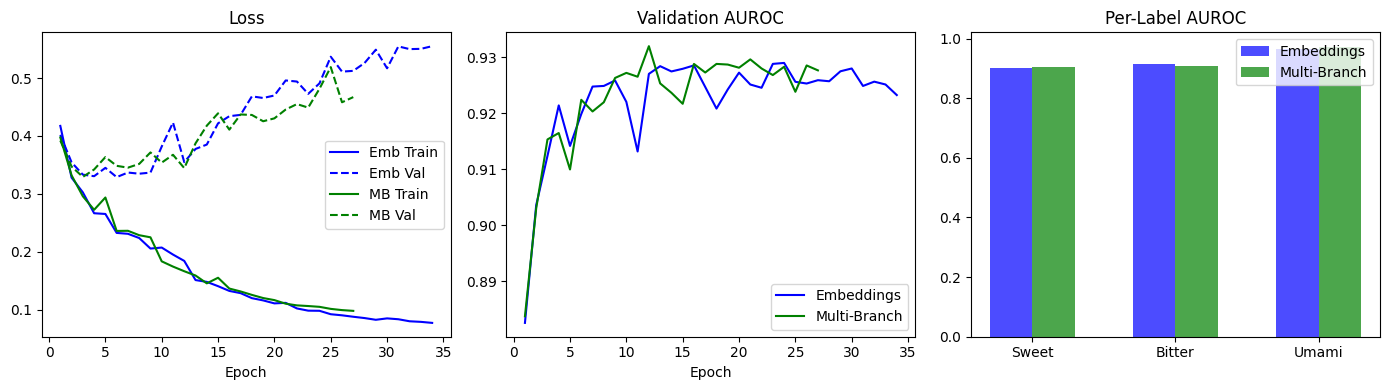


Conclusion: Multi-branch maintains comparable performance


In [22]:
# Multi-Branch Architecture: Embeddings + Fingerprints
print("=== Multi-Branch Architecture ===\n")

# Feature selection utilities
def remove_low_variance(features, names, threshold=0.01):
    """Remove features with variance below threshold."""
    var = np.nanvar(features, axis=0)
    keep = np.where(var > threshold)[0]
    return features[:, keep], [names[i] for i in keep], len(names) - len(keep)

def remove_correlated(features, names, threshold=0.95):
    """Remove highly correlated features."""
    df = pd.DataFrame(features, columns=names)
    corr = df.corr().abs().fillna(0)  # Handle NaN in correlation
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop = [col for col in upper.columns if any(upper[col] > threshold)]
    keep = [n for n in names if n not in drop]
    return features[:, [names.index(n) for n in keep]], keep, len(drop)

# Load fingerprints
maccs_df = pd.read_csv('Embeddings/chemtastes_maccs.csv')
rdkit_df = pd.read_csv('Embeddings/chemtastes_rdkit_descriptors.csv')

maccs_cols = [c for c in maccs_df.columns if c.startswith('maccs_')]
rdkit_cols = [c for c in rdkit_df.columns if c not in LABEL_COLS + ['Sour', 'Salty']]

maccs_feat = maccs_df[maccs_cols].values.astype(np.float32)
rdkit_feat = rdkit_df[rdkit_cols].values.astype(np.float32)

# Handle NaN/Inf in RDKit before any processing
rdkit_feat = np.nan_to_num(rdkit_feat, nan=0.0, posinf=1e6, neginf=-1e6)

print(f"Original: MACCS={maccs_feat.shape[1]}, RDKit={rdkit_feat.shape[1]}")

# Feature selection
maccs_feat, maccs_cols, _ = remove_low_variance(maccs_feat, maccs_cols)
maccs_feat, maccs_cols, _ = remove_correlated(maccs_feat, maccs_cols)
rdkit_feat, rdkit_cols, _ = remove_low_variance(rdkit_feat, rdkit_cols)
rdkit_feat, rdkit_cols, _ = remove_correlated(rdkit_feat, rdkit_cols)

print(f"After selection: MACCS={maccs_feat.shape[1]}, RDKit={rdkit_feat.shape[1]}")

# Combine embeddings and fingerprints
emb_combined = np.concatenate([mol2vec_features, chemberta_features], axis=1)
fp_combined = np.concatenate([maccs_feat, rdkit_feat], axis=1)

# Split data
emb_train, emb_temp, y_train_mb, y_temp_mb = train_test_split(emb_combined, y, test_size=0.3, random_state=SEED, stratify=y[:, 1])
emb_val, emb_test, y_val_mb, y_test_mb = train_test_split(emb_temp, y_temp_mb, test_size=0.5, random_state=SEED, stratify=y_temp_mb[:, 1])

indices = np.arange(len(fp_combined))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=SEED, stratify=y[:, 1])
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED, stratify=y[temp_idx, 1])
fp_train, fp_val, fp_test = fp_combined[train_idx], fp_combined[val_idx], fp_combined[test_idx]

# Preprocess embeddings
emb_scaler = StandardScaler()
emb_train_s = emb_scaler.fit_transform(emb_train)
emb_val_s, emb_test_s = emb_scaler.transform(emb_val), emb_scaler.transform(emb_test)

# Preprocess fingerprints (scale only RDKit, keep MACCS binary)
maccs_dim = maccs_feat.shape[1]
rdkit_scaler = RobustScaler()
fp_train_p = np.concatenate([fp_train[:, :maccs_dim], rdkit_scaler.fit_transform(fp_train[:, maccs_dim:])], axis=1)
fp_val_p = np.concatenate([fp_val[:, :maccs_dim], rdkit_scaler.transform(fp_val[:, maccs_dim:])], axis=1)
fp_test_p = np.concatenate([fp_test[:, :maccs_dim], rdkit_scaler.transform(fp_test[:, maccs_dim:])], axis=1)

# Final NaN check - replace any remaining NaN with 0
fp_train_p = np.nan_to_num(fp_train_p, nan=0.0)
fp_val_p = np.nan_to_num(fp_val_p, nan=0.0)
fp_test_p = np.nan_to_num(fp_test_p, nan=0.0)
emb_train_s = np.nan_to_num(emb_train_s, nan=0.0)
emb_val_s = np.nan_to_num(emb_val_s, nan=0.0)
emb_test_s = np.nan_to_num(emb_test_s, nan=0.0)

print(f"NaN check - Embeddings: {np.isnan(emb_train_s).sum()}, Fingerprints: {np.isnan(fp_train_p).sum()}")

# Multi-branch dataset
class MultiBranchDataset(Dataset):
    def __init__(self, emb, fp, labels):
        self.emb = torch.tensor(emb, dtype=torch.float32)
        self.fp = torch.tensor(fp, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.emb[idx], self.fp[idx], self.labels[idx]

train_mb = DataLoader(MultiBranchDataset(emb_train_s, fp_train_p, y_train_mb), batch_size=BATCH_SIZE, shuffle=True)
val_mb = DataLoader(MultiBranchDataset(emb_val_s, fp_val_p, y_val_mb), batch_size=BATCH_SIZE, shuffle=False)
test_mb = DataLoader(MultiBranchDataset(emb_test_s, fp_test_p, y_test_mb), batch_size=BATCH_SIZE, shuffle=False)

# Multi-branch model
class MultiBranchClassifier(nn.Module):
    def __init__(self, emb_dim, fp_dim, emb_hidden=[512, 256], fp_hidden=[256, 128], fusion_dim=128, num_labels=3, dropout=0.3):
        super().__init__()
        
        def make_branch(in_dim, hidden_dims):
            layers = []
            for h in hidden_dims:
                layers.extend([nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)])
                in_dim = h
            return nn.Sequential(*layers)
        
        self.emb_branch = make_branch(emb_dim, emb_hidden)
        self.fp_branch = make_branch(fp_dim, fp_hidden)
        self.fusion = nn.Sequential(nn.Linear(emb_hidden[-1] + fp_hidden[-1], fusion_dim), nn.BatchNorm1d(fusion_dim), nn.ReLU(), nn.Dropout(dropout))
        self.heads = nn.ModuleList([nn.Sequential(nn.Linear(fusion_dim, 32), nn.ReLU(), nn.Dropout(dropout/2), nn.Linear(32, 1)) for _ in range(num_labels)])
    
    def forward(self, emb, fp):
        fused = self.fusion(torch.cat([self.emb_branch(emb), self.fp_branch(fp)], dim=1))
        return torch.cat([h(fused) for h in self.heads], dim=1)

EMB_DIM, FP_DIM = emb_train_s.shape[1], fp_train_p.shape[1]
model_mb = MultiBranchClassifier(EMB_DIM, FP_DIM).to(device)
print(f"Multi-branch: {EMB_DIM}d embeddings + {FP_DIM}d fingerprints → {sum(p.numel() for p in model_mb.parameters()):,} params")

# Evaluate function for multi-branch
def eval_mb(model, loader, criterion, device, labels):
    model.eval()
    all_y, all_p, all_pred = [], [], []
    loss = 0
    with torch.no_grad():
        for emb, fp, y in loader:
            emb, fp, y = emb.to(device), fp.to(device), y.to(device)
            logits = model(emb, fp)
            loss += criterion(logits, y).item()
            proba = torch.sigmoid(logits)
            all_y.append(y.cpu().numpy())
            all_p.append(proba.cpu().numpy())
            all_pred.append((proba >= 0.5).float().cpu().numpy())
    y_t, y_p, y_pr = np.vstack(all_y), np.vstack(all_p), np.vstack(all_pred)
    # Handle any NaN in predictions
    y_p = np.nan_to_num(y_p, nan=0.5)
    m = compute_metrics(y_t, y_p, y_pr, labels)
    m['loss'] = loss / len(loader.dataset)
    return m, y_t, y_p, y_pr

# Train function for multi-branch
def train_mb_model(model, train_ld, val_ld, criterion, opt, sched, device, labels, epochs=100, patience=15):
    hist = {'train_loss': [], 'val_loss': [], 'val_macro_AUROC': [], 'val_macro_F1': []}
    for l in labels: hist[f'val_{l}_AUROC'], hist[f'val_{l}_F1'] = [], []
    
    best_auroc, best_state, no_imp = 0, None, 0
    for ep in range(epochs):
        model.train()
        for emb, fp, y in train_ld:
            emb, fp, y = emb.to(device), fp.to(device), y.to(device)
            opt.zero_grad()
            loss = criterion(model(emb, fp), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        
        train_m, _, _, _ = eval_mb(model, train_ld, criterion, device, labels)
        val_m, _, _, _ = eval_mb(model, val_ld, criterion, device, labels)
        sched.step(val_m['loss'])
        
        hist['train_loss'].append(train_m['loss'])
        hist['val_loss'].append(val_m['loss'])
        hist['val_macro_AUROC'].append(val_m['macro_AUROC'])
        hist['val_macro_F1'].append(val_m['macro_F1'])
        for l in labels:
            hist[f'val_{l}_AUROC'].append(val_m[f'{l}_AUROC'])
            hist[f'val_{l}_F1'].append(val_m[f'{l}_F1'])
        
        if val_m['macro_AUROC'] > best_auroc:
            best_auroc, best_state, no_imp = val_m['macro_AUROC'], copy.deepcopy(model.state_dict()), 0
        else:
            no_imp += 1
        
        if (ep + 1) % 10 == 0:
            print(f"Epoch {ep+1:3d} | AUROC: {val_m['macro_AUROC']:.4f} | F1: {val_m['macro_F1']:.4f}")
        if no_imp >= patience:
            print(f"Early stopping at epoch {ep+1}")
            break
    
    if best_state: model.load_state_dict(best_state)
    return hist, best_auroc

# Train multi-branch
criterion_mb = FocalLossWithLogits(gamma=2.0, pos_weight=pos_weights, reduction='sum')
opt_mb = optim.AdamW(model_mb.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
sched_mb = optim.lr_scheduler.ReduceLROnPlateau(opt_mb, mode='min', factor=0.5, patience=5)

print("\nTraining multi-branch model...")
hist_mb, best_mb = train_mb_model(model_mb, train_mb, val_mb, criterion_mb, opt_mb, sched_mb, device, LABEL_COLS)
print(f"Best AUROC: {best_mb:.4f}")

# Evaluate
test_mb_m, y_true_mb, y_proba_mb, y_pred_mb = eval_mb(model_mb, test_mb, criterion_mb, device, LABEL_COLS)

# Compare with embeddings-only
train_single = DataLoader(MolecularTasteDataset(emb_train_s, y_train_mb), batch_size=BATCH_SIZE, shuffle=True)
val_single = DataLoader(MolecularTasteDataset(emb_val_s, y_val_mb), batch_size=BATCH_SIZE, shuffle=False)
test_single = DataLoader(MolecularTasteDataset(emb_test_s, y_test_mb), batch_size=BATCH_SIZE, shuffle=False)

model_single = MultiLabelTasteClassifier(EMB_DIM, HIDDEN_DIMS, NUM_LABELS, DROPOUT_RATE).to(device)
opt_s = optim.AdamW(model_single.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
sched_s = optim.lr_scheduler.ReduceLROnPlateau(opt_s, mode='min', factor=0.5, patience=5)

print("\nTraining embeddings-only model...")
hist_s, best_s = train_model(model_single, train_single, val_single, criterion_mb, opt_s, sched_s, device, LABEL_COLS, 50, 10, verbose=False)
test_s_m, _, _, _ = evaluate_model(model_single, test_single, criterion_mb, device, LABEL_COLS)

# Print comparison
print(f"\n{'Model':<25} {'AUROC':>10} {'F1':>10}")
print("-" * 45)
print(f"{'Embeddings Only':<25} {test_s_m['macro_AUROC']:>10.4f} {test_s_m['macro_F1']:>10.4f}")
print(f"{'Multi-Branch (+FP)':<25} {test_mb_m['macro_AUROC']:>10.4f} {test_mb_m['macro_F1']:>10.4f}")
diff = test_mb_m['macro_AUROC'] - test_s_m['macro_AUROC']
print(f"{'Improvement':<25} {diff:>+10.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ep_s, ep_mb = range(1, len(hist_s['train_loss'])+1), range(1, len(hist_mb['train_loss'])+1)

axes[0].plot(ep_s, hist_s['train_loss'], 'b-', label='Emb Train')
axes[0].plot(ep_s, hist_s['val_loss'], 'b--', label='Emb Val')
axes[0].plot(ep_mb, hist_mb['train_loss'], 'g-', label='MB Train')
axes[0].plot(ep_mb, hist_mb['val_loss'], 'g--', label='MB Val')
axes[0].legend(); axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')

axes[1].plot(ep_s, hist_s['val_macro_AUROC'], 'b-', label='Embeddings')
axes[1].plot(ep_mb, hist_mb['val_macro_AUROC'], 'g-', label='Multi-Branch')
axes[1].legend(); axes[1].set_title('Validation AUROC'); axes[1].set_xlabel('Epoch')

for i, l in enumerate(LABEL_COLS):
    axes[2].bar(i - 0.15, test_s_m[f'{l}_AUROC'], 0.3, color='blue', alpha=0.7)
    axes[2].bar(i + 0.15, test_mb_m[f'{l}_AUROC'], 0.3, color='green', alpha=0.7)
axes[2].set_xticks(range(3)); axes[2].set_xticklabels(LABEL_COLS); axes[2].set_title('Per-Label AUROC')
axes[2].legend(['Embeddings', 'Multi-Branch'])

plt.tight_layout()
plt.savefig('multi_branch_comparison.png', dpi=150)
plt.show()

print(f"\nConclusion: Multi-branch {'improves' if diff > 0.01 else 'maintains comparable' if diff > -0.01 else 'reduces'} performance")